#### Step 1. Open the data file and study the general information

In [2]:
# import libraies 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pandas.plotting import scatter_matrix
from scipy import stats as st
from scipy.stats import ttest_ind

In [3]:
# Loading data 
df= pd.read_csv('/home/susan/videogame_sale_project/data/games.csv')
# make a  copy of data set 
videogame = df.copy()
print(videogame.info())
print('===='*30)
print()
print(videogame.columns)
print('===='*30)
print()
videogame.head()


<class 'pandas.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             16713 non-null  str    
 1   Platform         16715 non-null  str    
 2   Year_of_Release  16446 non-null  float64
 3   Genre            16713 non-null  str    
 4   NA_sales         16715 non-null  float64
 5   EU_sales         16715 non-null  float64
 6   JP_sales         16715 non-null  float64
 7   Other_sales      16715 non-null  float64
 8   Critic_Score     8137 non-null   float64
 9   User_Score       10014 non-null  str    
 10  Rating           9949 non-null   str    
dtypes: float64(6), str(5)
memory usage: 1.4 MB
None

Index(['Name', 'Platform', 'Year_of_Release', 'Genre', 'NA_sales', 'EU_sales',
       'JP_sales', 'Other_sales', 'Critic_Score', 'User_Score', 'Rating'],
      dtype='str')



,Name,Platform,Year_of_Release,Genre,NA_sales,EU_sales,JP_sales,Other_sales,Critic_Score,User_Score,Rating
0,Wii Sports,Wii,2006.0,Sports,41.36,28.96,3.77,8.45,76.0,8,E
1,Super Mario Bros.,NES,1985.0,Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008.0,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E
3,Wii Sports Resort,Wii,2009.0,Sports,15.61,10.93,3.28,2.95,80.0,8,E
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN


#### Step2 : Prepare the data

In [4]:
# Replace the column names (make them lowercase).
videogame.columns = (videogame.columns.str.strip()
                                      .str.lower())
print(videogame.columns)
print('===='*30)
print()
# Convert the data to the required types.
videogame['user_score'] = pd.to_numeric(videogame['user_score'], errors='coerce')
print(videogame['user_score'].dtype)
print('===='*30)
print()
# check for missing data  
print(videogame.isna().sum())
print('===='*30)
print()
# After missing value, we you do inspection to find out in which row data is missing 
# from 'name'.isna()which missing data
print(videogame[videogame['name'].isna()].head())
print('='*100)
print()
# filing missing value with mean or zero,unknown if they are number column = colum .fillna()
#  Fix categorical missing values
videogame['genre'] = videogame['genre'].fillna('Unknown')
videogame['rating'] = videogame['rating'].fillna('Unknown')
print(videogame.isna().sum())               

Index(['name', 'platform', 'year_of_release', 'genre', 'na_sales', 'eu_sales',
       'jp_sales', 'other_sales', 'critic_score', 'user_score', 'rating'],
      dtype='str')

float64

name                  2
platform              0
year_of_release     269
genre                 2
na_sales              0
eu_sales              0
jp_sales              0
other_sales           0
critic_score       8578
user_score         9125
rating             6766
dtype: int64

      name platform  year_of_release genre  na_sales  eu_sales  jp_sales  \
659    NaN      GEN           1993.0   NaN      1.78      0.53      0.00   
14244  NaN      GEN           1993.0   NaN      0.00      0.00      0.03   

       other_sales  critic_score  user_score rating  
659           0.08           NaN         NaN    NaN  
14244         0.00           NaN         NaN    NaN  

name                  2
platform              0
year_of_release     269
genre                 0
na_sales              0
eu_sales              0
jp_

In [5]:
#Check for duplicated data
print(f'The number of duplicated values are : {videogame.duplicated().sum()}')


The number of duplicated values are : 0


======================================================
## Step 3. Analyze the data

**3.1 Look at how many games were released in different years. Is the data for every period significant?**
=======================================================

In [6]:
print(videogame['year_of_release'].describe())
print('='*100)

# Games per individual year (remove .head() to see all)
videogame_per_year = (videogame.groupby('year_of_release')['name']
                               .count()
                               .reset_index()
                               .rename(columns={'name': 'game_count'}))
print(videogame_per_year)
print('='*100)

# Games per PERIOD (what the question actually asks)
bins = [1980, 1990, 2000, 2010, 2020]
labels = ['1980s', '1990s', '2000s', '2010s']

videogame['period'] = pd.cut(videogame['year_of_release'], 
                              bins=bins, 
                              labels=labels, 
                              right=False)

videogame_per_period = (videogame.groupby('period')['name']
                                  .count()
                                  .reset_index()
                                  .rename(columns={'name': 'game_count'}))
print(videogame_per_period)


count    16446.000000
mean      2006.484616
std          5.877050
min       1980.000000
25%       2003.000000
50%       2007.000000
75%       2010.000000
max       2016.000000
Name: year_of_release, dtype: float64
    year_of_release  game_count
0            1980.0           9
1            1981.0          46
2            1982.0          36
3            1983.0          17
4            1984.0          14
5            1985.0          14
6            1986.0          21
7            1987.0          16
8            1988.0          15
9            1989.0          17
10           1990.0          16
11           1991.0          41
12           1992.0          43
13           1993.0          60
14           1994.0         121
15           1995.0         219
16           1996.0         263
17           1997.0         289
18           1998.0         379
19           1999.0         338
20           2000.0         350
21           2001.0         482
22           2002.0         829
23           2003.

**3.2 Look at how sales varied from platform to platform. Choose the platforms with the greatest total sales and build a distribution based on data for each year. Find platforms that used to be popular but now have zero sales. How long does it generally take for new platforms to appear and old ones to fade?**

*`What the Question is Actually Asking — 3 Parts`*

* Top platforms by total sales ← you did this ✅
* Sales distribution per year for top platforms (line chart)
* How long platforms rise and fade

Top platforms by lifetime sales:
   platform  sale_per_platforms
16      PS2             1255.77
28     X360              971.42
17      PS3              939.65
26      Wii              907.51
4        DS              806.12
15       PS              730.86
6       GBA              317.85
18      PS4              314.14
19      PSP              294.05
13       PC              259.52
   platform  year_of_release  total_sale
33      PS3           2016.0        3.60
44      Wii           2016.0        0.18
56     X360           2016.0        1.52
32      PS3           2015.0       16.82
43      Wii           2015.0        1.14


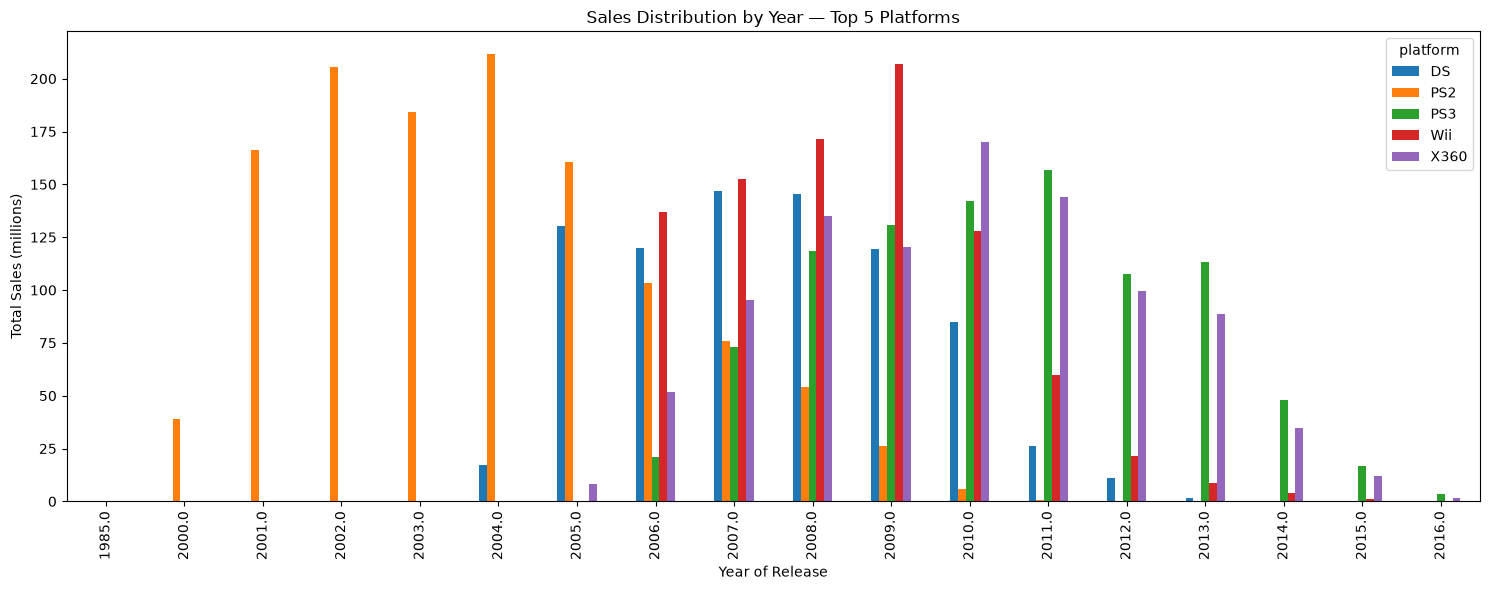

In [7]:
# platform and total sale
videogame['year_of_release'] = pd.to_numeric(videogame['year_of_release'], errors='coerce')
videogame['total_sale'] = (
    videogame['na_sales'] +
    videogame['eu_sales'] +
    videogame['jp_sales'] +
    videogame['other_sales']
)

platform_sales = (videogame.groupby('platform')['total_sale'].sum()
                            .reset_index()
                            .sort_values('total_sale', ascending=False)
                            .rename(columns={'total_sale': 'sale_per_platforms'})
                            .head(10))

print("Top platforms by lifetime sales:")
print(platform_sales)
print('===' * 30)

# PART 2 — Sales per year for TOP platforms
# tolist() converts pandas Series to a plain Python list
top_platforms = platform_sales['platform'].head(5).tolist()

# Filter original data to only those platforms
top_platform_data = videogame[videogame['platform'].isin(top_platforms)]

# Group by platform AND year
platform_year_sales = (
    top_platform_data
    .groupby(['platform', 'year_of_release'])['total_sale']
    .sum()
    .reset_index()
    .sort_values('year_of_release', ascending= False)
)

print(platform_year_sales.head())

# Pivot so each platform becomes its own column
platform_pivot = platform_year_sales.pivot(
    index='year_of_release',
    columns='platform',
    values='total_sale'
)

# Bar chart
platform_pivot.plot(
    kind='bar',
    title='Sales Distribution by Year — Top 5 Platforms',
    xlabel='Year of Release',
    ylabel='Total Sales (millions)',
    rot=90,
    figsize=(15, 6)
)

plt.tight_layout()
plt.show()



In [8]:
# How long does it generally take for new platforms to appear and old ones to fade?
print(videogame[['platform','year_of_release','total_sale']])
videogame['platform'].unique()
# For each platform, find:
# - first year it appeared
# - last year it had sales
# - how long it lasted

platform_lifespan = (videogame.groupby('platform')['year_of_release']
                               .agg(first_year='min', last_year='max')
                               .reset_index())

print('====='*30)
print(platform_lifespan)
platform_lifespan['lifespan_years'] = (platform_lifespan['last_year'] 
                                      - platform_lifespan['first_year'])

print(platform_lifespan.sort_values('first_year'))
print('===' * 30)
print(f"Average platform lifespan: {round(platform_lifespan['lifespan_years'].mean(), 1)} years")

      platform  year_of_release  total_sale
0          Wii           2006.0       82.54
1          NES           1985.0       40.24
2          Wii           2008.0       35.52
3          Wii           2009.0       32.77
4           GB           1996.0       31.38
...        ...              ...         ...
16710      PS3           2016.0        0.01
16711     X360           2006.0        0.01
16712      PSV           2016.0        0.01
16713      GBA           2003.0        0.01
16714      PSV           2016.0        0.01

[16715 rows x 3 columns]
   platform  first_year  last_year
0      2600      1980.0     1989.0
1       3DO      1994.0     1995.0
2       3DS      2011.0     2016.0
3        DC      1998.0     2008.0
4        DS      1985.0     2013.0
5        GB      1988.0     2001.0
6       GBA      2000.0     2007.0
7        GC      2001.0     2007.0
8       GEN      1990.0     1994.0
9        GG      1992.0     1992.0
10      N64      1996.0     2002.0
11      NES      1983.0   

==============================================================================================
**3.3**
* Determine what period you should take data for. To do so, look at your answers to the previous questions. 
The key criterion is that the data should allow you to build a prognosis for 2017(`You should not use all years. You should use only the years that are useful for predicting the next year, 2017.`)
* Work only with the data that you've decided is relevant. Disregard the data for previous years.
Which platforms are leading in sales? Which ones are growing or shrinking? Select several potentially profitable platforms.
=============================================================================================

<Axes: xlabel='platform'>

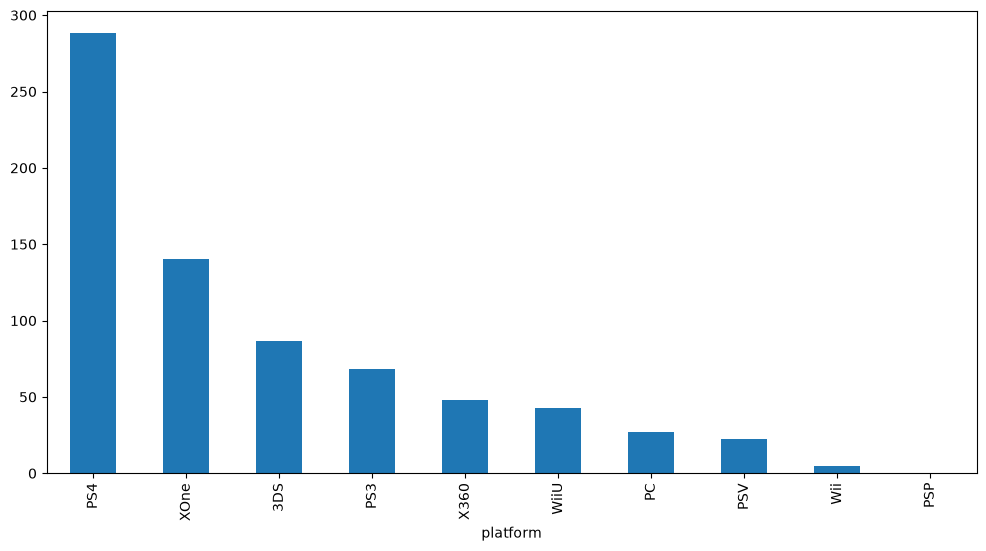

In [9]:
# Create filter 
videogame_pred = videogame[videogame['year_of_release']> 2013]

# Create groupby
platform_year_sales = (
    videogame_pred
    .groupby(['platform', 'year_of_release'])['total_sale']
    .sum()
    .reset_index()
    .sort_values(['platform', 'year_of_release'])
)

platform_sales = (
    videogame_pred
    .groupby('platform')['total_sale']
    .sum()
    .sort_values(ascending=False)
)
platform_sales.plot(kind='bar', figsize=(12, 6))







In [10]:
# Calculate platform sales by year and growth rates (%)
year_by_year_growth = (
    videogame_pred.groupby(['platform', 'year_of_release'])['total_sale']
    .sum()
    .reset_index()
    .pivot(index='platform', columns='year_of_release', values='total_sale')
    .fillna(0)
    .sort_index(axis=1)
)

# Convert year columns to integers for easier selection (e.g., 2014, 2015, 2016)
year_by_year_growth.columns = year_by_year_growth.columns.astype(int)

# Growth rate formula: ((new - old) / old) * 100
year_by_year_growth['growth_14_15'] = (
    (year_by_year_growth[2015] - year_by_year_growth[2014])
    / year_by_year_growth[2014].replace(0, np.nan)
    * 100
)

year_by_year_growth['growth_15_16'] = (
    (year_by_year_growth[2016] - year_by_year_growth[2015])
    / year_by_year_growth[2015].replace(0, np.nan)
    * 100
)

# View the platforms with the fastest recent growth
print(
    year_by_year_growth[['growth_14_15', 'growth_15_16']]
    .sort_values('growth_15_16', )
    .head(10)
)

year_of_release  growth_14_15  growth_15_16
platform                                   
PSP                -50.000000   -100.000000
X360               -65.572827    -87.290970
Wii                -69.600000    -84.210526
PS3                -64.782245    -78.596908
WiiU               -25.783023    -71.865443
XOne                11.226188    -56.518124
3DS                -36.517367    -45.500360
PS4                 18.900000    -41.757780
PC                 -35.843373    -38.380282
PSV                -47.478992    -32.000000


**3.4**
* Build a box plot for the global sales of all games, broken down by platform. Are the differences in sales significant? What about average sales on various platforms? Describe your findings.

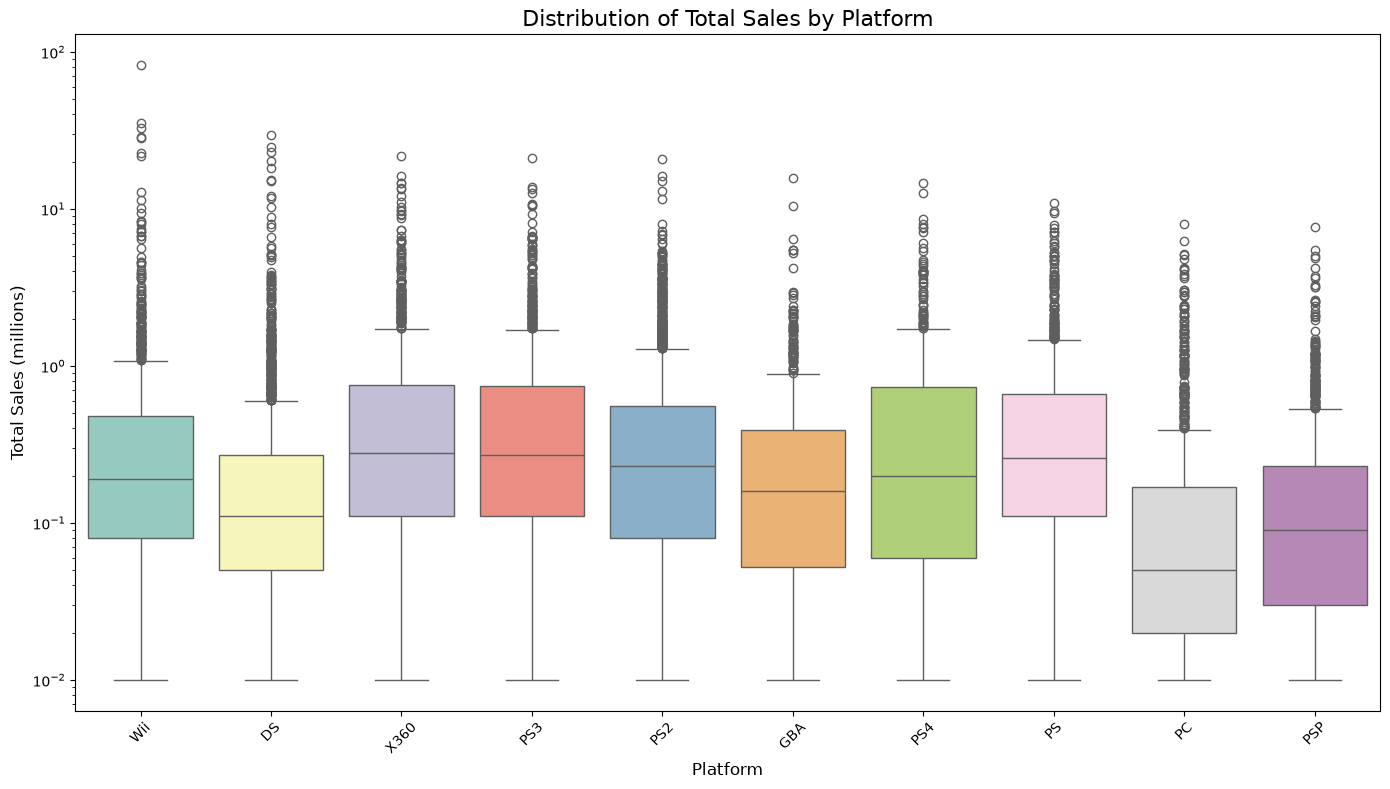

          count  mean  median    max
platform                            
PS4         392  0.80    0.20  14.63
X360       1262  0.77    0.28  21.82
PS3        1330  0.71    0.27  21.05
Wii        1320  0.69    0.19  82.54
PS         1197  0.61    0.26  10.95
PS2        2160  0.58    0.23  20.81
GBA         822  0.39    0.16  15.84
DS         2151  0.37    0.11  29.80
PC          974  0.27    0.05   8.01
PSP        1209  0.24    0.09   7.68


In [11]:
# Step 1: Build relevant dataframe
videogame_box = videogame[['platform', 'total_sale']].dropna().copy()

# Step 2: Keep top 10 platforms by lifetime sales for a cleaner x-axis
top10_platforms = (
    videogame_box.groupby('platform')['total_sale']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .index
)
videogame_box = videogame_box[videogame_box['platform'].isin(top10_platforms)]

# Step 3: For log scale, keep only strictly positive sales
videogame_box = videogame_box[videogame_box['total_sale'] > 0]

# Step 4: Draw the box plot in your requested style
plt.figure(figsize=(14, 8))
sns.boxplot(
    x='platform',
    y='total_sale',
    data=videogame_box,
    hue='platform',
    palette='Set3',
    legend=False
    )
plt.title('Distribution of Total Sales by Platform', fontsize=16)
plt.xlabel('Platform', fontsize=12)
plt.ylabel('Total Sales (millions)', fontsize=12)
plt.xticks(rotation=45)
plt.yscale('log')  # Log scale improves visibility across very different sales values
plt.tight_layout()
plt.show()

# Step 5: Summary table to support interpretation
platform_summary = (
    videogame_box.groupby('platform')['total_sale']
    .agg(['count', 'mean', 'median', 'max'])
    .sort_values('mean', ascending=False)
    .round(2)
)
print(platform_summary)

Take a look at how `user and professional reviews` affect sales for one popular platform (you choose). Build a scatter plot and calculate the correlation between reviews and sales. Draw conclusions.

Keeping your conclusions in mind, compare the sales of the same games on other platforms.



Index(['name', 'platform', 'year_of_release', 'genre', 'na_sales', 'eu_sales',
       'jp_sales', 'other_sales', 'critic_score', 'user_score', 'rating',
       'period', 'total_sale'],
      dtype='str')
<StringArray>
[ 'Wii',  'NES',   'GB',   'DS', 'X360',  'PS3',  'PS2', 'SNES',  'GBA',
  'PS4',  '3DS',  'N64',   'PS',   'XB',   'PC', '2600',  'PSP', 'XOne',
 'WiiU',   'GC',  'GEN',   'DC',  'PSV',  'SAT',  'SCD',   'WS',   'NG',
 'TG16',  '3DO',   'GG', 'PCFX']
Length: 31, dtype: str
       total_sale  critic_score
count  249.000000    249.000000
mean     0.981004     72.132530
std      1.646217     12.550965
min      0.010000     19.000000
25%      0.080000     66.000000
50%      0.300000     74.000000
75%      1.100000     80.000000
max     12.620000     97.000000
                                        name  critic_score  user_score  \
42                        Grand Theft Auto V          97.0         8.3   
77                                   FIFA 16          82.0         4.3 

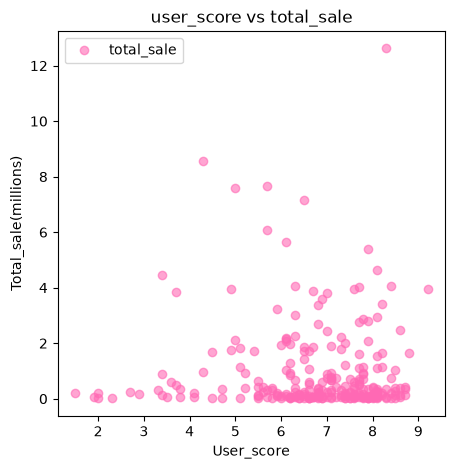

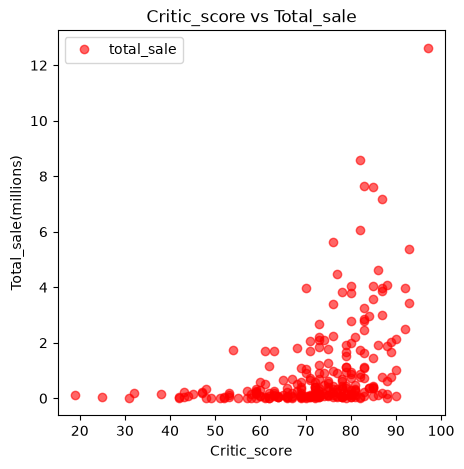

Correlation: user_score vs total_sale = -0.034
Correlation: critic_score vs total_sale = 0.406


In [12]:
print(videogame.columns)
print(videogame['platform'].unique())
# Choose a platform with high total sales (from your earlier platform totals).
mask = videogame['platform']== 'PS4'
# Confirm total_sale is numeric and positive.
videogame['total_sale'] = pd.to_numeric(videogame['total_sale'], errors='coerce')

# Build the right mini-dataset
# Keep only rows for that platform.
# Keep only these columns: user_score, critic_score, total_sale, and game name. 

review_sale = videogame[videogame['platform']== 'PS4'][['name','critic_score', 'user_score','total_sale']].dropna()
print(review_sale[['total_sale','critic_score']].describe())  

print(review_sale)
# Create two scatter plots (not one)
# Scatter plot: user Score vs Total Sales
review_sale.plot(title = 'user_score vs total_sale', y ='total_sale', x ='user_score', style ='o', alpha =0.6,
        figsize = [5,5],
        ylabel = 'Total_sale(millions)', 
        xlabel = 'User_score',  color='hotpink') 
plt.savefig("user_score vs total_sale.png", dpi=150, bbox_inches="tight")  # 
plt.show()
 # Scatter plot:critic_ Score vs Total Sales  
review_sale.plot(title = 'Critic_score vs Total_sale', y ='total_sale', x ='critic_score', style ='o', alpha =0.6,
        figsize = [5,5],
        ylabel = 'Total_sale(millions)', 
        xlabel = 'Critic_score',  color='red') 
plt.savefig("Critic_score vs total_sale.png", dpi=150, bbox_inches="tight")  # 
plt.show()  

# Calculate two correlations
# Correlation 1: user_score with total_sale
corr_user = review_sale['user_score'].corr(review_sale['total_sale'])
# Correlation 2: critic_score with total_sale
corr_critic = review_sale['critic_score'].corr(review_sale['total_sale'])

print('Correlation: user_score vs total_sale =', round(corr_user, 3))
print('Correlation: critic_score vs total_sale =', round(corr_critic, 3))

In [13]:
# Repeat PS4-style review analysis for all platforms
videogame['total_sale'] = pd.to_numeric(videogame['total_sale'], errors='coerce')
# step 1 : loop platform
corr_rows = []# Create an empty list.
for platform in sorted(videogame['platform'].dropna().unique()): #Go through each unique platform name, one by one, in sorted order.
    temp = videogame.loc[videogame['platform'] == platform, ['name', 'critic_score', 'user_score', 'total_sale']].dropna()
# Build a temporary mini-table for only this platform.
# Keep only the needed columns.
# dropna() removes rows with missing values in any of those columns.
    # Need at least 3 rows to compute meaningful correlations
    if len(temp) < 3:
        continue

    corr_user = temp['user_score'].corr(temp['total_sale'])
    corr_critic = temp['critic_score'].corr(temp['total_sale'])

    corr_rows.append({
        'platform': platform,
        'games_used': len(temp),
        'corr_user_total_sale': corr_user,
        'corr_critic_total_sale': corr_critic
    })
if len(temp) < 3:# Check if this platform has too few rows.Correlation with tiny data is unstable.
    pass
#Compute Pearson correlation between user_score and total_sale for this platform.
corr_user = temp['user_score'].corr(temp['total_sale'])
# Compute Pearson correlation between critic_score and total_sale for this platform.
corr_critic = temp['critic_score'].corr(temp['total_sale'])
# Add one dictionary row to results list containing:
corr_rows.append({
    'platform': platform,
    'games_used': len(temp),
    'corr_user_total_sale': corr_user,
    'corr_critic_total_sale': corr_critic
})
platform_review_corr = (
#Start building final summary table from all dictionaries.

pd.DataFrame(corr_rows)
#Convert list of dictionaries into a DataFrame.
.sort_values('corr_critic_total_sale', ascending=False)
.reset_index(drop=True)# Reset row numbers to 0,1,2... after sorting.
.round(3)
#Round numeric values to 3 decimals for cleaner output.
)
# Finish creating the DataFram
print('Correlation summary by platform (sorted by critic correlation):')
print(platform_review_corr)

# Optional: show top platforms with enough rows to be reliable
reliable = platform_review_corr[platform_review_corr['games_used'] >= 20]
print('\nPlatforms with >=20 games (more reliable):')
print(reliable)

Correlation summary by platform (sorted by critic correlation):
   platform  games_used  corr_user_total_sale  corr_critic_total_sale
0        PS         156                 0.298                   0.429
1       PS3         790                 0.143                   0.428
2      XOne         165                -0.094                   0.410
3      XOne         165                -0.094                   0.410
4       PS4         249                -0.034                   0.406
5      X360         881                 0.110                   0.390
6       PS2        1161                 0.169                   0.389
7        XB         581                 0.181                   0.370
8      WiiU          89                 0.392                   0.351
9        DC          14                -0.303                   0.350
10      3DS         158                 0.233                   0.340
11       GC         356                 0.240                   0.302
12      PSP         393   

**Excellent result set for interpretation.**

`user_score vs total_sale = -0.034`

This is essentially no relationship (very weak, near zero). For PS4 games in your sample, user scores do not meaningfully explain sales.

`critic_score vs total_sale = 0.406`

This is a moderate positive relationship. Higher critic scores are associated with higher sales, noticeably more than user scores.

Conclusion you can write:
For the selected popular platform (PS4), professional reviews have a stronger association with sales than user reviews. User scores show almost no linear connection to sales, while critic scores show a moderate positive correlation. This suggests critic reception may be more informative for predicting sales on this platform, though correlation does not prove causation.

genre
Action          1744.17
Sports          1331.27
Shooter         1052.45
Role-Playing     934.56
Platform         827.77
Misc             802.51
Racing           728.67
Fighting         447.53
Simulation       389.97
Puzzle           242.57
Adventure        237.59
Strategy         174.23
Unknown            2.42
Name: total_sale, dtype: float64


<Axes: title={'center': 'Sales Distribution by Genre '}, xlabel='Genre', ylabel='Total Sales (millions)'>

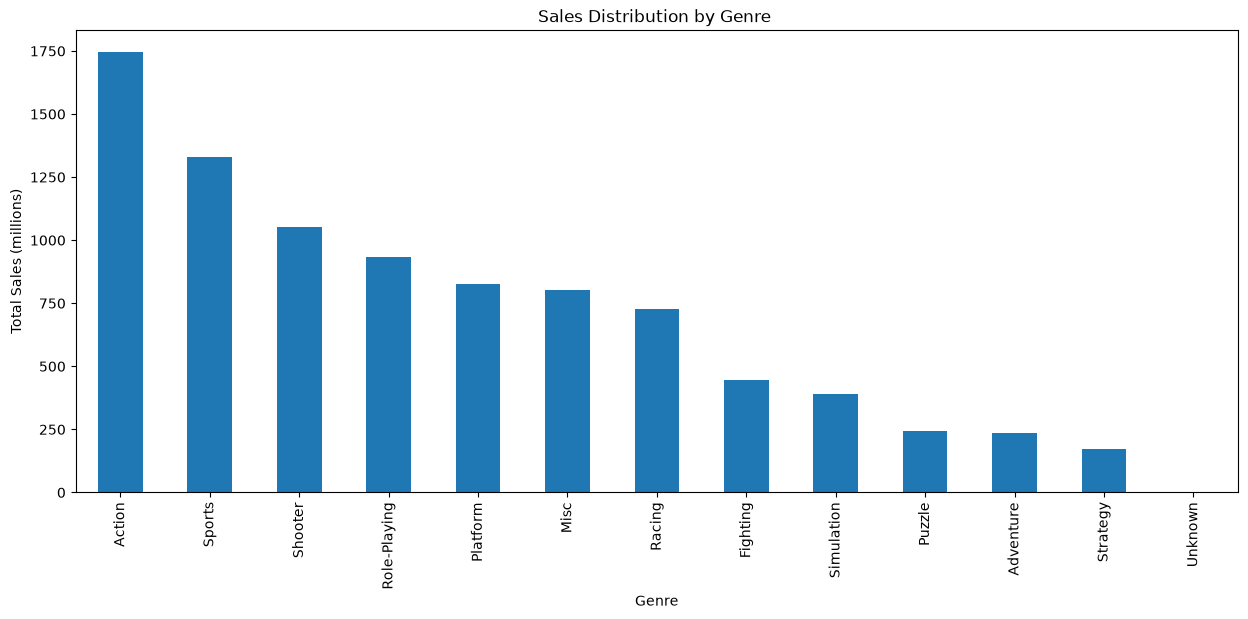

In [14]:
# Take a look at the general distribution of games by genre. What can we say about the most profitable genres? Can you generalize about genres with high and low sales?
# create a table platform, genre, total sale
genre_profit = (videogame.groupby(['genre'])['total_sale'].sum()
              .sort_values(ascending= False)
              .fillna(0))
      

print(genre_profit)       
# Bar chart
genre_profit.plot(
    kind='bar',
    title='Sales Distribution by Genre ',
    xlabel='Genre',
    ylabel='Total Sales (millions)',
    rot=90,
    figsize=(15, 6))

<div  padding:10px; border-radius:10px;">
<span style="color:green; font-weight:bold">** Total Sales by Genre:**</span>

This plot shows the Action genre has the highest total sales (200+ million) compared to Strategy with the lowest total sales (8 million).The bar plot shows a **right-skewed distribution** because there are a few genres with very high sales while most genres have moderate to low sales.

#### Key Insights:
* **Top performers**: Action and Shooter genres dominate the market with significantly higher sales
* **Market concentration**: The top 4 genres (Action, Shooter, Sports, Role-Playing) account for the majority of total sales
* **Long tail**: Many genres (Fighting, Racing, Platform, Adventure, Simulation, Strategy, Puzzle) have relatively low sales, creating the right skew in the distribution
</div>

**Step 4. Create a user profile for each region**

For each region (NA, EU, JP), determine:

* The top five platforms. Describe variations in their market shares from region to region.
* The top five genres. Explain the difference.
* Do ESRB ratings affect sales in individual regions?

In [15]:
#* The top five platforms. Describe variations in their market shares from region to region.
#Find market share from region to region 
#  Create mini -table
user_profile_na = videogame[['platform','na_sales']]

performe_na = (user_profile_na.groupby('platform')['na_sales'].sum()
                    .reset_index()
                   .sort_values('na_sales', 
                               ascending=False))
# market share
performe_na['na_share_pct'] = performe_na['na_sales'] / performe_na['na_sales'].sum() * 100
print(performe_na.head(5))                                 


   platform  na_sales  na_share_pct
28     X360    602.47     13.685191
16      PS2    583.84     13.262008
26      Wii    496.90     11.287153
17      PS3    393.49      8.938181
4        DS    382.40      8.686270


=======================================
Pseudo-structure (no full code, just logic):

* for region in [na, eu, jp]:

* table = groupby platform -> sum(region)
* table['share_%'] = table[region] / table[region].sum() * 100
 * print(top 5)
 

   platform  na_share_pct  eu_share_pct  jp_share_pct
28     X360        13.685        11.167         0.958
16      PS2        13.262        13.993        10.729
26      Wii        11.287        10.814         5.344
17      PS3         8.938        13.622         6.181
4        DS         8.686         7.790        13.533
   platform  na_share_pct  eu_share_pct  jp_share_pct
16      PS2        13.262        13.993        10.729
17      PS3         8.938        13.622         6.181
28     X360        13.685        11.167         0.958
26      Wii        11.287        10.814         5.344
15       PS         7.644         8.810        10.777
   platform  na_share_pct  eu_share_pct  jp_share_pct
4        DS         8.686         7.790        13.533
15       PS         7.644         8.810        10.777
16      PS2        13.262        13.993        10.729
23     SNES         1.391         0.785         8.984
2       3DS         1.896         2.536         7.760


<Axes: title={'center': 'Top 5 platforms by market share (NA, EU, JP)'}, xlabel='Platform', ylabel='Market share (%)'>

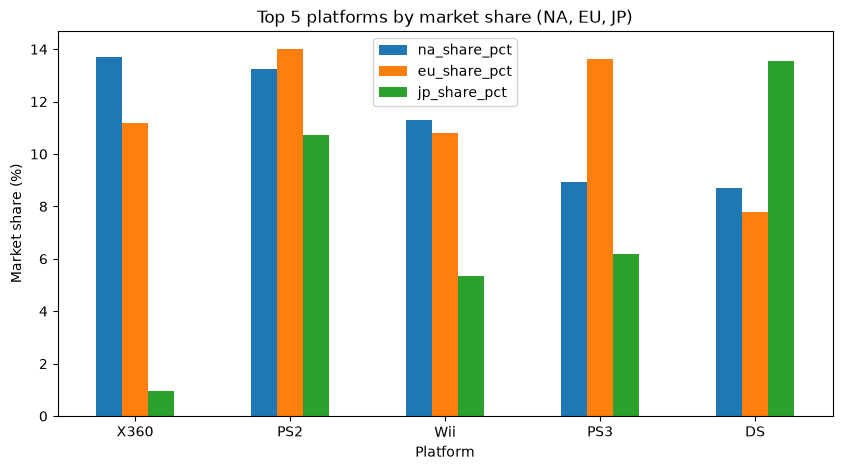

In [16]:
 # top five platforms. Describe variations in their market shares from region to region.
# Total sales by platform first
platform_totals = (videogame.groupby('platform')[['na_sales', 'eu_sales', 'jp_sales']]
                   .sum()
                   .reset_index())

# Region totals (denominator for market share)
na_total = platform_totals['na_sales'].sum()
eu_total = platform_totals['eu_sales'].sum()
jp_total = platform_totals['jp_sales'].sum()

market_rows = []
for _, row in platform_totals.iterrows():#Go row-by-row through the platform_totals DataFrame.
    market_rows.append({
        'platform': row['platform'],
        'na_share_pct': (row['na_sales'] / na_total) * 100,
        'eu_share_pct': (row['eu_sales'] / eu_total) * 100,
        'jp_share_pct': (row['jp_sales'] / jp_total) * 100
    })

platform_share_market = pd.DataFrame(market_rows).round(3)
print(platform_share_market.sort_values('na_share_pct', ascending=False).head(5))
print(platform_share_market.sort_values('eu_share_pct', ascending=False).head(5))
print(platform_share_market.sort_values('jp_share_pct', ascending=False).head(5))

top5_share = (
platform_share_market
.sort_values('na_share_pct', ascending=False)
.head(5)
.set_index('platform')
)

top5_share[['na_share_pct', 'eu_share_pct', 'jp_share_pct']].plot(
kind='bar',
figsize=(10, 5),
title='Top 5 platforms by market share (NA, EU, JP)',
ylabel='Market share (%)',
xlabel='Platform',
rot=0
)

       genre  na_share_pct  eu_share_pct  jp_share_pct
0     Action        19.967        21.410        12.443
10    Sports        15.547        15.540        10.447
8    Shooter        13.453        13.088         2.988
4   Platform        10.120         8.263        10.084
3       Misc         9.251         8.774         8.333
      genre  na_share_pct  eu_share_pct  jp_share_pct
0    Action        19.967        21.410        12.443
10   Sports        15.547        15.540        10.447
8   Shooter        13.453        13.088         2.988
6    Racing         8.163         9.754         4.371
3      Misc         9.251         8.774         8.333
           genre  na_share_pct  eu_share_pct  jp_share_pct
7   Role-Playing         7.514         7.783        27.395
0         Action        19.967        21.410        12.443
10        Sports        15.547        15.540        10.447
4       Platform        10.120         8.263        10.084
3           Misc         9.251         8.774       

<Axes: title={'center': 'Top 5 genres by market share (NA, EU, JP)'}, xlabel='Genre', ylabel='Market share (%)'>

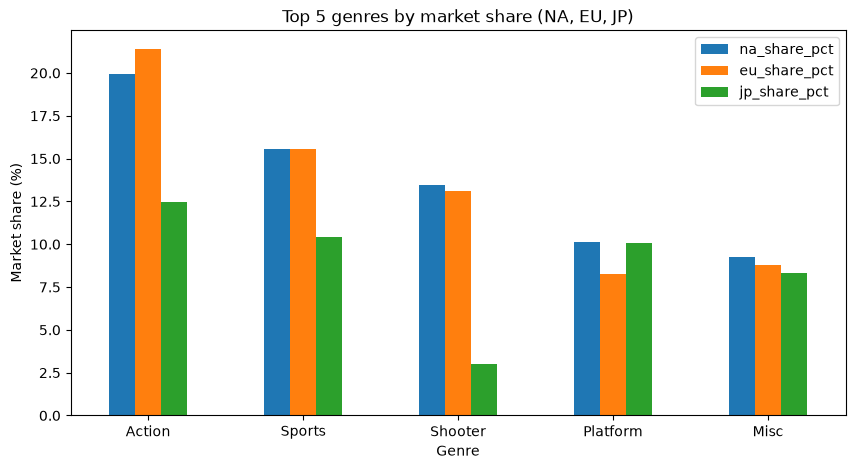

In [19]:
# The top five genres. Explain the difference
genre_totals = (videogame.groupby('genre')[['na_sales', 'eu_sales', 'jp_sales']]
                   .sum()
                   .reset_index())

# Region totals (denominator for market share)
na_total = genre_totals['na_sales'].sum()
eu_total = genre_totals['eu_sales'].sum()
jp_total = genre_totals['jp_sales'].sum()

genre_rows = []
for _, row in genre_totals.iterrows():
    genre_rows.append({
        'genre': row['genre'],
        'na_share_pct': (row['na_sales'] / na_total) * 100,
        'eu_share_pct': (row['eu_sales'] / eu_total) * 100,
        'jp_share_pct': (row['jp_sales'] / jp_total) * 100
    })

genre_share_market = pd.DataFrame(genre_rows).round(3)
print(genre_share_market.sort_values('na_share_pct', ascending=False).head(5))
print(genre_share_market.sort_values('eu_share_pct', ascending=False).head(5))
print(genre_share_market.sort_values('jp_share_pct', ascending=False).head(5))

top5_share_genre = (
genre_share_market
.sort_values('na_share_pct', ascending=False)
.head(5)
.set_index('genre')
)

top5_share_genre[['na_share_pct', 'eu_share_pct', 'jp_share_pct']].plot(
kind='bar',
figsize=(10, 5),
title='Top 5 genres by market share (NA, EU, JP)',
ylabel='Market share (%)',
xlabel='Genre',
rot=0
)

    rating  na_share_pct  eu_share_pct  jp_share_pct
1        E        29.370        29.293        15.270
8  Unknown        28.223        25.316        64.897
7        T        17.258        17.612        11.670
5        M        17.002        19.960         4.952
2     E10+         8.026         7.775         3.099
    rating  na_share_pct  eu_share_pct  jp_share_pct
1        E        29.370        29.293        15.270
8  Unknown        28.223        25.316        64.897
5        M        17.002        19.960         4.952
7        T        17.258        17.612        11.670
2     E10+         8.026         7.775         3.099
    rating  na_share_pct  eu_share_pct  jp_share_pct
8  Unknown        28.223        25.316        64.897
1        E        29.370        29.293        15.270
7        T        17.258        17.612        11.670
5        M        17.002        19.960         4.952
2     E10+         8.026         7.775         3.099


<Axes: title={'center': 'Top 5 ratings by market share (NA, EU, JP)'}, xlabel='Rating', ylabel='Market share (%)'>

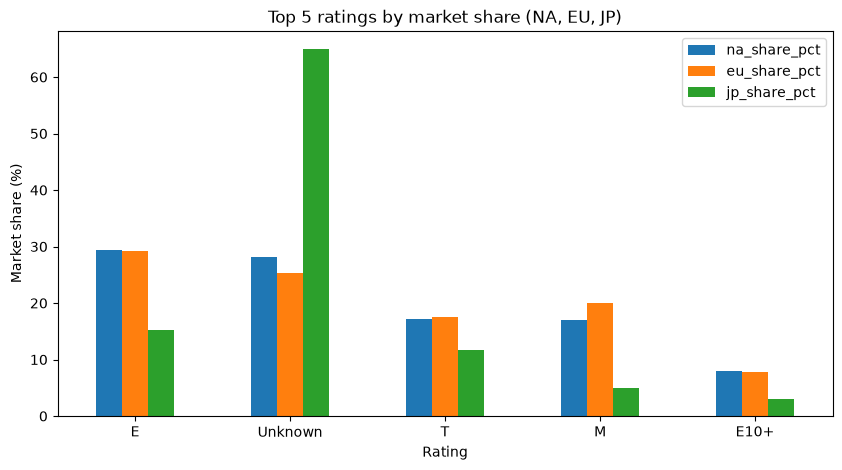

In [18]:
# Do ESRB ratings affect sales in individual regions?
ESRB_totals = (videogame.groupby('rating')[['na_sales', 'eu_sales', 'jp_sales']]
               .sum()
               .reset_index())

# Region totals (denominator for market share)
na_total = ESRB_totals['na_sales'].sum()
eu_total = ESRB_totals['eu_sales'].sum()
jp_total = ESRB_totals['jp_sales'].sum()

ESRB_rows = []
for _, row in ESRB_totals.iterrows():  # Go row-by-row through ESRB_totals
    ESRB_rows.append({
        'rating': row['rating'],
        'na_share_pct': (row['na_sales'] / na_total) * 100,
        'eu_share_pct': (row['eu_sales'] / eu_total) * 100,
        'jp_share_pct': (row['jp_sales'] / jp_total) * 100
    })

ESRB_share_market = pd.DataFrame(ESRB_rows).round(3)

print(ESRB_share_market.sort_values('na_share_pct', ascending=False).head(5))
print(ESRB_share_market.sort_values('eu_share_pct', ascending=False).head(5))
print(ESRB_share_market.sort_values('jp_share_pct', ascending=False).head(5))

top5_share_ESRB = (
    ESRB_share_market
    .sort_values('na_share_pct', ascending=False)
    .head(5)
    .set_index('rating')
)

top5_share_ESRB[['na_share_pct', 'eu_share_pct', 'jp_share_pct']].plot(
    kind='bar',
    figsize=(10, 5),
    title='Top 5 ratings by market share (NA, EU, JP)',
    ylabel='Market share (%)',
    xlabel='Rating',
    rot=0
)